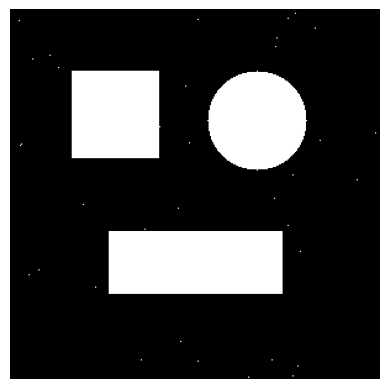

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = np.zeros((300, 300), dtype=np.uint8)

cv2.rectangle(image, (50, 50), (120, 120), 255, -1)
cv2.circle(image, (200, 90), 40, 255, -1)
cv2.rectangle(image, (80, 180), (220, 230), 255, -1)

noise = np.random.randint(0, 300, (40, 2))
for x, y in noise:
    image[y, x] = 255

plt.imshow(image, cmap='gray')
plt.axis('off')
plt.show()

kernel = np.ones((5, 5), np.uint8)
circle_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

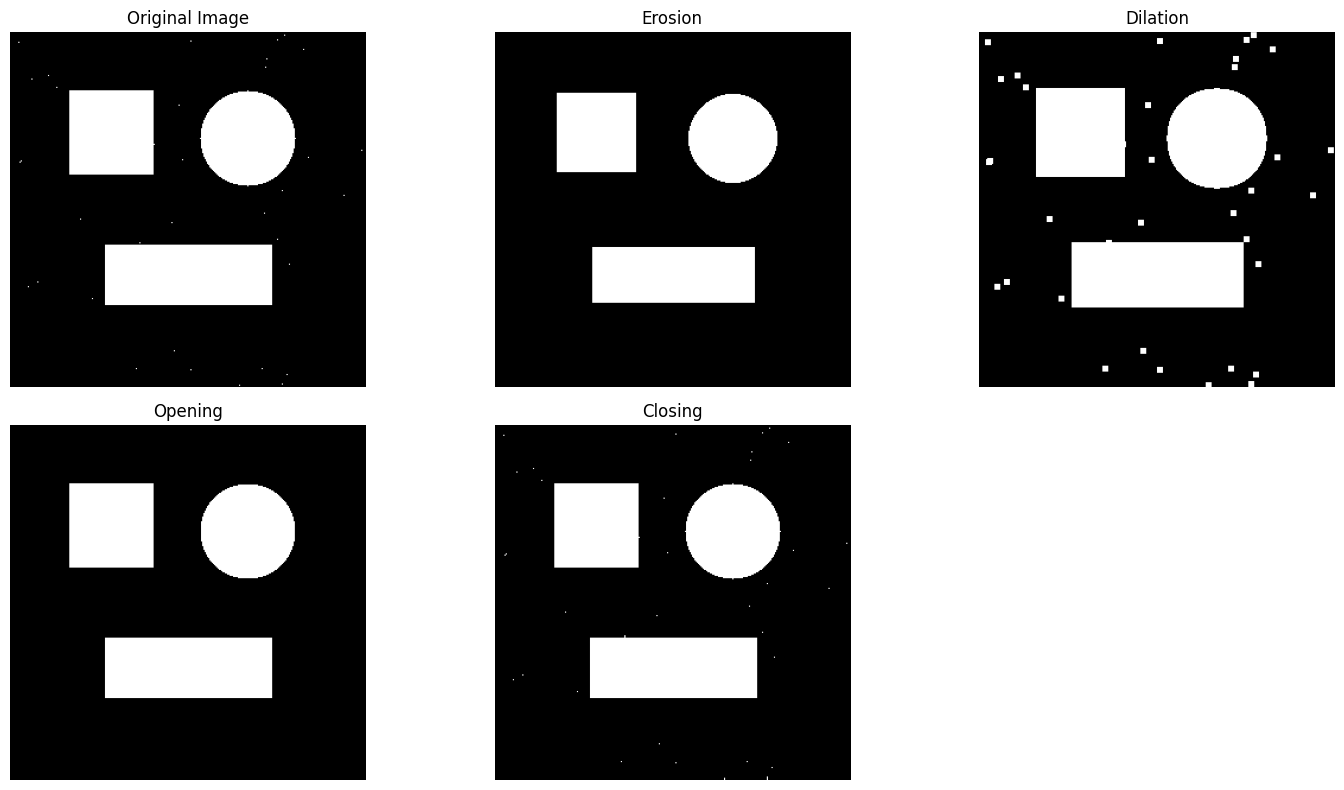

In [10]:
erosion = cv2.erode(image, kernel, iterations=1)
dilation = cv2.dilate(image, kernel, iterations=1)
opening = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernel)

titles = ['Original Image', 'Erosion', 'Dilation', 'Opening', 'Closing']
images = [image, erosion, dilation, opening, closing]

plt.figure(figsize=(15, 8))

for i in range(len(images)):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

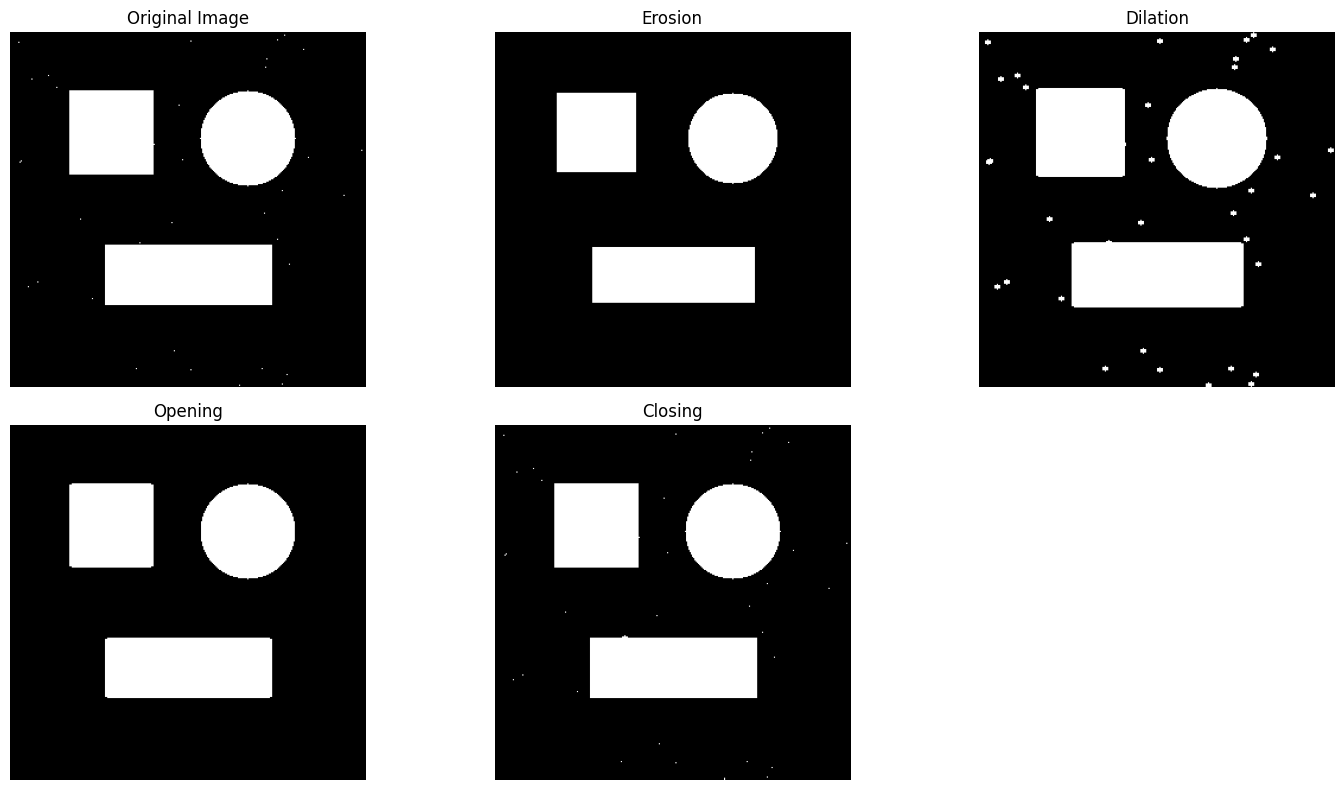

In [11]:
erosion_circle = cv2.erode(image, circle_kernel, iterations=1)
dilation_circle = cv2.dilate(image, circle_kernel, iterations=1)
opening_circle = cv2.morphologyEx(image, cv2.MORPH_OPEN, circle_kernel)
closing_circle = cv2.morphologyEx(image, cv2.MORPH_CLOSE, circle_kernel)

titles_circle = ['Original Image', 'Erosion', 'Dilation', 'Opening', 'Closing']
images_circle = [image, erosion_circle, dilation_circle, opening_circle, closing_circle]

plt.figure(figsize=(15, 8))

for i in range(len(images_circle)):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images_circle[i], cmap='gray')
    plt.title(titles_circle[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

The square kernel affects the shapes more strongly in horizontal and vertical directions, so it may make rounded objects look slightly less smooth.

The circular kernel preserves curved objects better because its shape is closer to the objects in the image.

Erosion makes white objects smaller, while dilation makes them larger. Opening removes small white noise, and closing fills small gaps or holes.